# Question 3: Insights and Use Cases

## Assignment
> On insights and use cases:
> - What first impressions do you get from this data?
> - Name three use cases for this dataset (assume you might also combine it with other public or Adevinta datasets).


## 1. Link With Question 2

Question 2 uses this dataset as an A/B testing problem: define the lead KPI, check whether A and B are comparable, estimate the result, and explain the risks around causal interpretation.

Question 3 uses the same data differently. The goal is not to prove whether the feature caused an uplift, but to ask what the car-ad data suggests about marketplace behavior and what business use cases it can support.

I reuse the q2 lead definition:

`has_any_lead = telclicks > 0 OR bids > 0 OR n_asq > 0 OR webclicks > 0`

I also reuse q2's caveat: descriptive patterns are useful for product and business thinking, but they are not causal claims unless supported by an experiment or a stronger modelling design.


In [1]:
from pathlib import Path
import sys
import importlib

import pandas as pd
from IPython.display import display

helper_dir = Path.cwd()
if not (helper_dir / "functions.py").exists():
    helper_dir = Path.cwd() / "assignments" / "data_analyst"
if str(helper_dir) not in sys.path:
    sys.path.insert(0, str(helper_dir))

import functions as helpers

helpers = importlib.reload(helpers)

pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 80)
helpers.plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
raw_data = helpers.read_ab_test_data(helpers.DATA_PATH)

insight_data = raw_data.copy()
metric_columns = helpers.existing_columns(insight_data, helpers.METRIC_COLUMNS)
insight_data[metric_columns] = insight_data[metric_columns].fillna(0)
insight_data["has_any_lead"] = insight_data[metric_columns].gt(0).any(axis=1)
insight_data["total_leads"] = insight_data[metric_columns].sum(axis=1)
insight_data["car_age"] = insight_data["bouwjaar"].max() - insight_data["bouwjaar"]
insight_data = helpers.add_segments(insight_data)

ab_data, excluded_data = helpers.prepare_ab_data(raw_data)
segmented_ab_data = helpers.add_segments(ab_data)

print(f"Rows available for q3 insights: {len(insight_data):,}")
print(f"Rows assigned to A/B groups in q2: {len(ab_data):,}")
print(f"Rows not assigned to an A/B group: {len(excluded_data):,} ({len(excluded_data) / len(raw_data):.1%})")


Rows available for q3 insights: 183,062
Rows assigned to A/B groups in q2: 174,449
Rows not assigned to an A/B group: 8,613 (4.7%)


The q2 notebook already established a few foundations that I do not need to repeat in detail here: most rows can be used for the A/B comparison, a small share have missing group assignment, duplicate ad IDs are rare, and B has a higher observed lead rate than A. For q3, the useful carry-over is mainly the lead KPI and the warning that group-level experiment findings should stay separate from broader descriptive insights.


In [3]:
q2_bridge = pd.DataFrame(
    {
        "q2 item": [
            "Lead KPI",
            "Data caveats",
            "A/B result",
            "Interpretation boundary",
        ],
        "how q3 uses it": [
            "Use the same binary lead indicator as the main marketplace-interest outcome.",
            "Keep missing group rows and duplicate IDs in mind, but do not let test-assignment issues dominate q3.",
            "Mention only as context; q3 is not another A/B readout.",
            "Treat q3 patterns as descriptive unless a later experiment or model supports causality.",
        ],
    }
)

display(helpers.style_table(q2_bridge))


,Q2 Item,How Q3 Uses It
0,Lead KPI,Use the same binary lead indicator as the main marketplace-interest outcome.
1,Data caveats,"Keep missing group rows and duplicate IDs in mind, but do not let test-assignment issues dominate q3."
2,A/B result,Mention only as context; q3 is not another A/B readout.
3,Interpretation boundary,Treat q3 patterns as descriptive unless a later experiment or model supports causality.


## 2. First Impressions

This section intentionally starts broad. The aim is to collect the most plausible first impressions, then later narrow to the ones that are most interesting and presentation-worthy.


### 2.1 Marketplace Funnel Shape

The dataset is strongest around buyer interest in live ads. It measures whether an ad generated leads, but it does not show the full marketplace funnel from search exposure to sale.


In [4]:
funnel_scope = pd.DataFrame(
    {
        "covered in this data": [
            "Ad/listing attributes",
            "Vehicle attributes",
            "Lead outcomes",
            "Experiment group assignment",
        ],
        "not covered in this data": [
            "Search impressions or ranking position",
            "Seller history and seller quality",
            "Buyer identity or buyer journey",
            "Final sale, sale price, revenue, margin, or lead quality",
        ],
        "implication": [
            "Good for listing optimization and descriptive lead analysis.",
            "Good for segmenting demand by car type, but not enough for final value.",
            "Good proxy for buyer interest, but not guaranteed conversion.",
            "Need additional datasets before making ROI or transaction-success claims.",
        ],
    }
)

display(helpers.style_table(funnel_scope))


,Covered In This Data,Not Covered In This Data,Implication
0,Ad/listing attributes,Search impressions or ranking position,Good for listing optimization and descriptive lead analysis.
1,Vehicle attributes,Seller history and seller quality,"Good for segmenting demand by car type, but not enough for final value."
2,Lead outcomes,Buyer identity or buyer journey,"Good proxy for buyer interest, but not guaranteed conversion."
3,Experiment group assignment,"Final sale, sale price, revenue, margin, or lead quality",Need additional datasets before making ROI or transaction-success claims.


### 2.2 Lead Channel Mix

The four lead fields may represent different buyer intent. A website click, phone click, bid, and seller question are all leads, but they probably do not have the same commercial meaning.


,Channel,Rows With Event,Share of Ads With Event,Average Events Per Ad,Share of All Lead Events
3,Web Clicks,"97,931",0.535,2.739,0.514
2,Questions,"60,485",0.330,0.991,0.186
0,Tel Clicks,"57,429",0.314,0.917,0.172
1,Bids,"30,908",0.169,0.678,0.127


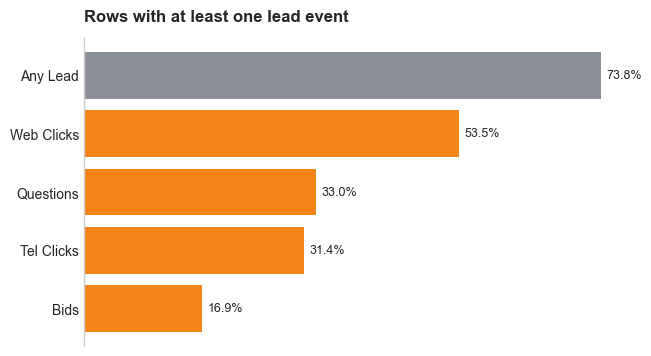

In [5]:
channel_mix = []
for column in helpers.METRIC_COLUMNS:
    channel_mix.append(
        {
            "channel": helpers.DISPLAY_VALUE_ALIASES.get(column, column),
            "rows_with_event": int(insight_data[column].gt(0).sum()),
            "share_of_ads_with_event": insight_data[column].gt(0).mean(),
            "average_events_per_ad": insight_data[column].mean(),
            "share_of_all_lead_events": insight_data[column].sum() / insight_data[helpers.METRIC_COLUMNS].sum().sum(),
        }
    )
channel_mix = pd.DataFrame(channel_mix).sort_values("share_of_all_lead_events", ascending=False)

display(helpers.style_table(channel_mix))
helpers.plot_lead_channel_coverage(insight_data)
helpers.plt.show()


This is useful beyond q2 because channel mix can shape product decisions. If channels behave differently, a single `has_any_lead` KPI is good for a headline view but not enough for understanding lead quality or seller value.


### 2.3 Skew and Concentration

Lead generation is likely concentrated: many ads get some interest, while a smaller group receives a large number of total leads. That matters because averages can overstate the typical seller experience.


,Metric,Value
0,Ads with at least one lead,0.738
1,Median total leads per ad,2
2,90th percentile total leads,14
3,99th percentile total leads,40
4,Share of lead events from top decile ads,0.487


,Metric,Value
0,Count,"183,062"
1,Mean,5.325
2,Std,9.246
3,Min,0
4,25%,0
5,50%,2
6,75%,7
7,90%,14
8,95%,20
9,99%,40


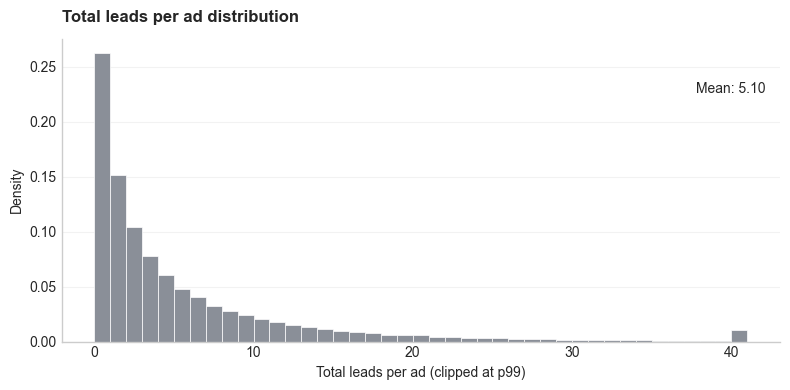

In [6]:
lead_distribution = insight_data["total_leads"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).reset_index()
lead_distribution.columns = ["metric", "value"]

top_10_cutoff = insight_data["total_leads"].quantile(0.90)
top_10 = insight_data.loc[insight_data["total_leads"] >= top_10_cutoff]
concentration = pd.DataFrame(
    {
        "metric": [
            "Ads with at least one lead",
            "Median total leads per ad",
            "90th percentile total leads",
            "99th percentile total leads",
            "Share of lead events from top decile ads",
        ],
        "value": [
            insight_data["has_any_lead"].mean(),
            insight_data["total_leads"].median(),
            insight_data["total_leads"].quantile(0.90),
            insight_data["total_leads"].quantile(0.99),
            top_10["total_leads"].sum() / insight_data["total_leads"].sum(),
        ],
    }
)

display(helpers.style_table(concentration))
display(helpers.style_table(lead_distribution))
helpers.plot_total_leads_distribution(insight_data)
helpers.plt.show()


- Lead volume is highly skewed: many ads receive few leads, while a small group receives many.
- Business implication: use median, percentile, and concentration views alongside averages.
- This helps separate typical seller experience from high-performing outliers.

### 2.4 Listing Quality Signals

Some fields describe how the ad is presented rather than what the car is. These are interesting because sellers or Marktplaats can potentially influence them.


,Photo Count Band,Ads,Lead Rate,Avg Leads/Ad,Median Days Live,Median Price,Share of Ads
0,0-5,"8,630",0.797,8.092,31.000,"18,500.000",0.047
1,6-12,"61,208",0.816,6.968,31.000,"29,000.000",0.334
2,13-20,"57,750",0.730,4.934,31.000,"59,950.000",0.315
3,21+,"55,474",0.650,3.488,31.000,"117,450.000",0.303


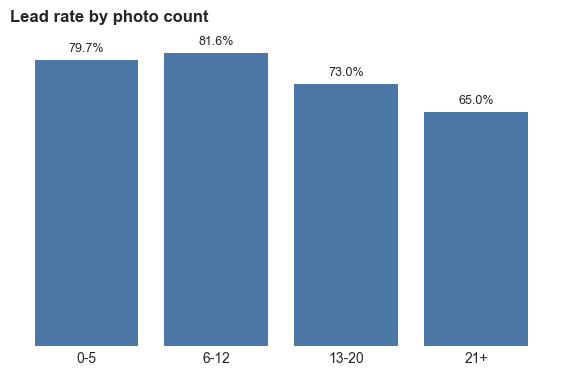

In [7]:
listing_quality = (
    insight_data.dropna(subset=["photo_count_band"])
    .groupby("photo_count_band", observed=True)
    .agg(
        ads=("src_ad_id", "count"),
        lead_rate=("has_any_lead", "mean"),
        avg_total_leads=("total_leads", "mean"),
        median_days_live=("days_live", "median"),
        median_price=("price", "median"),
    )
    .reset_index()
)
listing_quality["share_of_ads"] = listing_quality["ads"] / len(insight_data)

display(helpers.style_table(listing_quality))

fig, ax = helpers.plt.subplots(figsize=(7, 4))
helpers.plot_labeled_vertical_bars(
    ax,
    listing_quality["photo_count_band"].astype(str),
    listing_quality["lead_rate"],
    "Lead rate by photo count",
    ylabel="Lead rate",
    colors=helpers.PLOT_COLORS["A"],
    percent_y=True,
    percent_labels=True,
)
helpers.plt.show()


Photo count is especially practical: unlike brand, model, or mileage, it is a seller action. If the pattern is strong enough after controlling for car type and price, it could become seller guidance or an automated listing-quality recommendation.


### 2.5 Vehicle Attribute Demand Patterns

Vehicle fields are useful for understanding demand. They may not be directly changeable by sellers, but they help marketplace teams understand which segments attract more interest.


In [8]:
def segment_insight_summary(dataframe, segment_column, min_ads=500):
    summary = (
        dataframe.dropna(subset=[segment_column])
        .groupby(segment_column, observed=True)
        .agg(
            ads=("src_ad_id", "count"),
            lead_rate=("has_any_lead", "mean"),
            avg_total_leads=("total_leads", "mean"),
            median_price=("price", "median"),
            median_photos=("photo_cnt", "median"),
        )
        .reset_index()
    )
    summary = summary.loc[summary["ads"] >= min_ads].copy()
    summary["share_of_ads"] = summary["ads"] / len(dataframe)
    return summary.sort_values("lead_rate", ascending=False)

for segment_column in ["price_band", "km_band", "car_age_band"]:
    display(helpers.style_table(segment_insight_summary(insight_data, segment_column)))


,Price Band,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Photos,Share of Ads
0,0-25k,"52,340",0.885,8.689,"11,500.000",11.000,0.286
1,25k-60k,"42,250",0.799,5.815,"39,990.000",14.000,0.231
2,60k-120k,"43,290",0.664,3.524,"87,450.000",18.000,0.236
3,120k+,"45,175",0.580,2.694,"184,450.000",22.000,0.247


,Mileage Band,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Photos,Share of Ads
3,200k+,"45,272",0.860,7.167,"22,500.000",12.000,0.247
2,150k-200k,"35,863",0.825,6.583,"39,450.000",14.000,0.196
1,75k-150k,"56,374",0.748,5.117,"69,500.000",16.000,0.308
0,0-75k,"44,149",0.524,2.525,"139,000.000",20.000,0.241


,Car Age Band,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Photos,Share of Ads
3,13+,"50,442",0.877,8.113,"14,500.000",11.000,0.276
2,8-12,"52,457",0.815,6.184,"44,950.000",14.000,0.287
1,4-7,"45,914",0.695,3.941,"97,500.000",18.000,0.251
0,0-3,"34,249",0.470,1.757,"169,950.000",22.000,0.187


In [9]:
body_type_summary = segment_insight_summary(insight_data, "carrosserie", min_ads=1000).head(10)
brand_summary = segment_insight_summary(insight_data, "brand", min_ads=1000).head(10)

display(helpers.style_table(body_type_summary))
display(helpers.style_table(brand_summary))


,Body Type,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Photos,Share of Ads
1,Coup,"2,913",0.863,7.863,"89,500.000",17.000,0.016
5,Sedan (2/4-deurs),"15,472",0.841,7.035,"59,500.000",16.000,0.085
4,Overige carrosserie n,"2,494",0.769,5.712,"34,250.000",12.000,0.014
0,Cabriolet,"5,290",0.759,4.677,"69,900.000",17.000,0.029
6,Stationwagon,"29,233",0.742,4.709,"69,500.000",17.000,0.160
7,Terreinwagen,"10,128",0.729,4.649,"169,400.000",21.000,0.055
2,Hatchback (3/5-deurs),"79,944",0.719,5.614,"49,500.000",14.000,0.437
3,MPV,"19,737",0.692,3.879,"49,990.000",16.000,0.108


,Brand,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Photos,Share of Ads
12,AUDI,"7,062",0.845,6.658,"122,475.000",19.000,0.039
37,DAEWOO,"1,070",0.829,7.456,"9,995.000",10.000,0.006
40,DAIHATSU,"1,052",0.825,6.743,"19,500.000",12.000,0.006
3,ALFA ROMEO,"1,577",0.824,6.674,"44,950.000",15.000,0.009
187,VOLKSWAGEN,"22,148",0.803,6.862,"69,000.000",15.000,0.121
20,BMW,"9,259",0.801,6.919,"119,900.000",20.000,0.051
123,MERCEDES,"7,809",0.796,6.481,"124,500.000",18.000,0.043
165,SEAT,"4,906",0.794,5.771,"47,125.000",14.000,0.027
120,MAZDA,"2,398",0.784,5.169,"33,675.000",14.000,0.013
31,CHEVROLET,"1,513",0.767,5.743,"38,500.000",14.000,0.008


These segment views were too exploratory for the q2 A/B story, but they fit q3 well. They can support inventory planning, merchandising, seller education, and commercial targeting.


### 2.6 Dataset Limitations

The dataset is useful, but the missing pieces matter. These limitations also point directly to useful joins with other public or Adevinta datasets.


In [10]:
limitations = pd.DataFrame(
    {
        "limitation": [
            "No final sale outcome",
            "No buyer journey",
            "No seller history",
            "No search exposure or ranking data",
            "No lead quality or duplicate-lead flag",
            "Limited causal interpretation outside q2 test setup",
        ],
        "why it matters": [
            "Cannot tell whether leads converted into transactions.",
            "Cannot distinguish browsing behavior from serious purchase intent.",
            "Cannot separate listing effect from seller reputation or responsiveness.",
            "Cannot know whether low leads reflect weak demand or low visibility.",
            "Cannot tell whether more leads are actually better leads.",
            "Descriptive segment differences may reflect confounding.",
        ],
        "useful extra data": [
            "Transaction/sale data, final sale price, listing close reason.",
            "Search logs, clickstream, saved ads, buyer cohorts.",
            "Seller tenure, response speed, ratings, subscription/product history.",
            "Impressions, search rank, recommendation placement, paid exposure.",
            "Lead follow-up, response, conversion, spam/duplicate indicators.",
            "Experiment metadata, exposure logs, or modelling controls.",
        ],
    }
)

display(helpers.style_table(limitations))


,Limitation,Why It Matters,Useful Extra Data
0,No final sale outcome,Cannot tell whether leads converted into transactions.,"Transaction/sale data, final sale price, listing close reason."
1,No buyer journey,Cannot distinguish browsing behavior from serious purchase intent.,"Search logs, clickstream, saved ads, buyer cohorts."
2,No seller history,Cannot separate listing effect from seller reputation or responsiveness.,"Seller tenure, response speed, ratings, subscription/product history."
3,No search exposure or ranking data,Cannot know whether low leads reflect weak demand or low visibility.,"Impressions, search rank, recommendation placement, paid exposure."
4,No lead quality or duplicate-lead flag,Cannot tell whether more leads are actually better leads.,"Lead follow-up, response, conversion, spam/duplicate indicators."
5,Limited causal interpretation outside q2 test setup,Descriptive segment differences may reflect confounding.,"Experiment metadata, exposure logs, or modelling controls."


## 3. Which Ad Characteristics Relate to Leads?

These comparisons are descriptive, not causal. They show how ads with at least one lead differ from ads without leads. This is useful for identifying candidate drivers to investigate more rigorously later.


In [11]:
numeric_fields = ["price", "kmstand", "car_age", "photo_cnt", "days_live", "vermogen"]
lead_profile = (
    insight_data.groupby("has_any_lead")[numeric_fields]
    .median()
    .T
    .rename(columns={False: "no_lead_median", True: "lead_median"})
    .reset_index()
    .rename(columns={"index": "dimension"})
)
lead_profile["difference_lead_minus_no_lead"] = lead_profile["lead_median"] - lead_profile["no_lead_median"]
lead_profile["pct_difference_vs_no_lead"] = lead_profile["difference_lead_minus_no_lead"] / lead_profile["no_lead_median"]

display(helpers.style_table(lead_profile))


has_any_lead,Dimension,No Lead Median,Lead Median,Difference Lead Minus No Lead,Percent Difference vs No Lead
0,Price,"99,000.000","46,450.000","-52,550.000",-0.531
1,Mileage,"88,921.000","152,759.000","63,838.000",0.718
2,Car Age,5.000,10.000,5.000,1.000
3,Photos,18.000,14.000,-4.000,-0.222
4,Days Live,31.000,31.000,0.000,0.000
5,Power,75.000,77.000,2.000,0.027


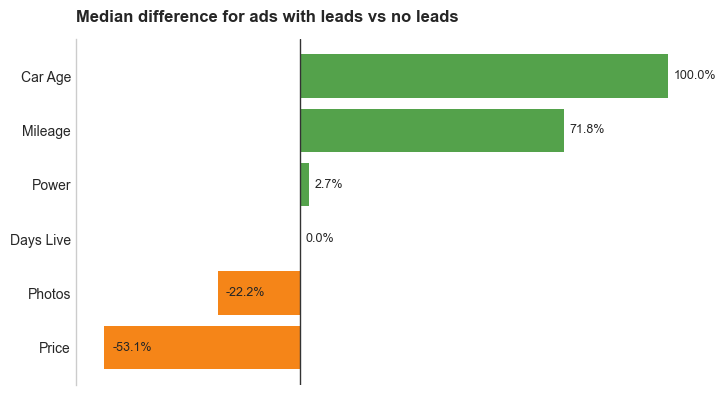

In [12]:
plot_profile = lead_profile.dropna(subset=["pct_difference_vs_no_lead"]).sort_values("pct_difference_vs_no_lead")
fig, ax = helpers.plt.subplots(figsize=(8, 4.5))
helpers.plot_labeled_horizontal_bars(
    ax,
    plot_profile["dimension"].map(helpers.DISPLAY_VALUE_ALIASES).fillna(plot_profile["dimension"]),
    plot_profile["pct_difference_vs_no_lead"],
    "Median difference for ads with leads vs no leads",
    xlabel="Percent difference",
    colors=helpers.signed_difference_colors(plot_profile["pct_difference_vs_no_lead"]),
    percent_x=True,
    percent_labels=True,
    zero_line=True,
)
helpers.plt.show()


## 4. Candidate Insights To Narrow Later

The broad first-impression pass suggests several possible storylines. I would narrow to the strongest ones after reviewing the tables and charts together.


In [13]:
candidate_insights = pd.DataFrame(
    {
        "candidate insight": [
            "Lead type matters",
            "Lead volume is skewed",
            "Listing quality may be actionable",
            "Vehicle segments reveal demand patterns",
            "Dataset is a lead-interest dataset, not a transaction dataset",
        ],
        "why it is interesting": [
            "A single any-lead KPI is good for simplicity, but product teams may care about channel quality.",
            "Averages can be pulled by high-performing ads, so seller experience needs median/percentile views.",
            "Photo count and ad presentation are things sellers and product nudges can influence.",
            "Price, mileage, age, body type, and brand can guide supply, merchandising, and targeting decisions.",
            "The missing funnel pieces naturally motivate dataset joins and future analysis.",
        ],
        "keep for final answer?": [
            "Likely",
            "Likely",
            "Likely",
            "Likely, but choose only 1-2 segment cuts",
            "Definitely",
        ],
    }
)

display(helpers.style_table(candidate_insights))


,Candidate Insight,Why It Is Interesting,Keep For Final Answer?
0,Lead type matters,"A single any-lead KPI is good for simplicity, but product teams may care about channel quality.",Likely
1,Lead volume is skewed,"Averages can be pulled by high-performing ads, so seller experience needs median/percentile views.",Likely
2,Listing quality may be actionable,Photo count and ad presentation are things sellers and product nudges can influence.,Likely
3,Vehicle segments reveal demand patterns,"Price, mileage, age, body type, and brand can guide supply, merchandising, and targeting decisions.","Likely, but choose only 1-2 segment cuts"
4,"Dataset is a lead-interest dataset, not a transaction dataset",The missing funnel pieces naturally motivate dataset joins and future analysis.,Definitely


## 5. Three Business Use Cases

The dataset is most valuable when converted into repeatable decision systems. These three use cases are realistic with the current fields, and each becomes stronger if combined with additional Adevinta or public data.


In [14]:
use_cases = pd.DataFrame(
    {
        "use case": [
            "Seller listing optimization",
            "Marketplace supply and demand intelligence",
            "Commercial product targeting",
        ],
        "how this dataset helps": [
            "Estimate which listing choices and car attributes are associated with lead generation, then give sellers concrete guidance on photos, pricing bands, and promotion timing.",
            "Identify categories, brands, body types, price bands, and mileage bands with strong buyer interest, then compare demand against available supply.",
            "Target paid visibility, lead-boosting products, or seller bundles toward listings and sellers where incremental exposure is most likely to create value.",
        ],
        "data to combine later": [
            "Seller history, listing edit history, image quality, local competition, and final sale outcomes.",
            "Search demand, buyer location, macroeconomic indicators, public vehicle registrations, fuel prices, and regional inventory data.",
            "Seller subscription status, product purchase history, margins, churn risk, lead quality, and downstream conversion/revenue.",
        ],
        "example decision": [
            "Show a seller that similar cars with more photos or a different price band tend to receive more leads.",
            "Prioritize acquisition or merchandising for high-demand segments where supply is thin.",
            "Offer the right paid product to listings with strong conversion potential rather than blanket discounting.",
        ],
    }
)

display(helpers.style_table(use_cases))


,Use Case,How This Dataset Helps,Data To Combine Later,Example Decision
0,Seller listing optimization,"Estimate which listing choices and car attributes are associated with lead generation, then give sellers concrete guidance on photos, pricing bands, and promotion timing.","Seller history, listing edit history, image quality, local competition, and final sale outcomes.",Show a seller that similar cars with more photos or a different price band tend to receive more leads.
1,Marketplace supply and demand intelligence,"Identify categories, brands, body types, price bands, and mileage bands with strong buyer interest, then compare demand against available supply.","Search demand, buyer location, macroeconomic indicators, public vehicle registrations, fuel prices, and regional inventory data.",Prioritize acquisition or merchandising for high-demand segments where supply is thin.
2,Commercial product targeting,"Target paid visibility, lead-boosting products, or seller bundles toward listings and sellers where incremental exposure is most likely to create value.","Seller subscription status, product purchase history, margins, churn risk, lead quality, and downstream conversion/revenue.",Offer the right paid product to listings with strong conversion potential rather than blanket discounting.


## 6. Recommendation

I would keep q2 and q3 as separate notebooks. Q2 should stay focused on experiment setup, A/B comparability, the primary result, and test risks. Q3 should own the broader marketplace insight story: lead-channel behavior, skew, listing-quality signals, vehicle-demand segments, limitations, and business use cases.

Final takeaway: this data is strong for understanding and improving lead generation. It should be paired with seller, buyer, revenue, exposure, and conversion data before using it for ROI decisions, pricing policy, or causal product claims.
